In [1]:
from May31_Frank2D_CPU import *

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from constants import rad_to_arcsec, deg_to_rad
from scipy.stats import binned_statistic
from matplotlib.colors import LogNorm

# frank1d utilities
from frank.geometry import SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

__all__ = [
    "Plot",
]

class Plot(object):
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._Geometry = Geometry
        self._u_gridded, self._v_gridded = self._frank2d._gridded_data['u'], self._frank2d._gridded_data['v']
        self._vis_gridded, self._weights_gridded = self._frank2d._gridded_data['vis'], self._frank2d._gridded_data['weights']
        self._Nx = Frank2D._Nx
        self._Ny = Frank2D._Ny

        
    def intensity_model(self, title="Frank2D intensity model", deproject = False, zoom = None, fig_size = 6, vmax = 4e10):
        frank2d = self._frank2d
        I = frank2d.sol_intensity
        x_ = frank2d._FT._Xn * rad_to_arcsec
        y_ = frank2d._FT._Yn * rad_to_arcsec
        Nx, Ny = self._Nx, self._Ny
        x, y = x_, y_

        # Deprojection.
        inc_r = self._Geometry._inc * deg_to_rad
        pa_r = self._Geometry._pa * deg_to_rad

        cos_i = np.cos(inc_r)
        cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
        
        if deproject:
            x = (x_ * cos_pa + y_ * sin_pa) / cos_i
            y = (x_ * -sin_pa + y_ * cos_pa)

        plt.figure(figsize=(fig_size, fig_size))

        X = x.reshape(Ny, Nx)
        Y = y.reshape(Ny, Nx)
        I = I.reshape(Ny, Nx)

        I_flip = np.fliplr(I)
        X_flip = -np.fliplr(X)

        plot = plt.pcolormesh(X_flip, Y, I_flip,
                              cmap='magma', vmin=0, vmax=vmax)
        plt.gca().invert_xaxis()
        cmap = plt.colorbar(plot, shrink=0.8)
        cmap.set_label(r'I [Jy $sr^{-1}$]', size=15)

        plt.title(title)
        plt.xlabel("dRa ['']")
        plt.ylabel("dDec ['']")

        plt.gca().set_aspect(1)  


        xlim = plt.xlim()
        ylim = plt.ylim()
        
        lims = [xlim[1], xlim[0]]

        if zoom is not None:
            plt.xlim(zoom, -zoom)
            plt.ylim(-zoom, zoom)
        else:
            plt.text(
            lims[0] + 0.8 * (lims[1] - lims[0]),  
            lims[0] + 0.1 * (lims[1] - lims[0]),  
            r'  $'+ str(Nx) + '^{2}$ pixels ',
            bbox={'facecolor': 'white', 'pad': 4, 'alpha': 0.8}
        )

        plt.show()


    def visibility_model(self, title="Frank2D visibility model", deproject = False):
            frank2d = self._frank2d
            Nx, Ny = self._Nx, self._Ny

            vis_model = frank2d.sol_visibility.reshape(Nx, Ny)
            
            u, v = frank2d._FT._Un, frank2d._FT._Vn

            u_shifted, v_shifted = np.fft.fftshift(u.reshape(Nx, Ny)), np.fft.fftshift(v.reshape(Nx, Ny))
            vis_shifted = np.fft.fftshift(vis_model)

            if deproject: 
                u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

            plt.pcolormesh(v_shifted,
                           u_shifted,
                           np.log(np.abs(vis_shifted)),
                           cmap="viridis", vmin=-12, vmax=-2)
            plt.xlabel(r'u [ $\lambda$]')
            plt.ylabel(r'v [ $\lambda$]')
            plt.gca().set_aspect('equal') 
            cmap = plt.colorbar(shrink=0.8)
            cmap.set_label(r'V [Jy]', size=15)
            plt.title(r'log|$Vis_{model}$|')
            plt.show()

    def visibility_masked_model(self, title="Frank2D visibility model", deproject = False, percentil = 97):
            frank2d = self._frank2d
            Nx, Ny = self._Nx, self._Ny

            vis_model = frank2d.sol_visibility.reshape(Nx, Ny)
            
            u, v = frank2d._FT._Un, frank2d._FT._Vn

            u_shifted, v_shifted = np.fft.fftshift(u.reshape(Nx, Ny)), np.fft.fftshift(v.reshape(Nx, Ny))
            vis_shifted = np.fft.fftshift(vis_model)

            if deproject: 
                u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

            abs_vis = np.abs(vis_shifted)
            log_abs_vis = np.log(abs_vis)
            threshold = np.percentile(abs_vis, percentil)
        
            mask_high = abs_vis > threshold
            mask_low = ~mask_high
        
            data_low = np.ma.masked_where(mask_high, log_abs_vis)
            data_high = np.ma.masked_where(mask_low, log_abs_vis)
        
            fig, ax = plt.subplots()
            p1 = ax.pcolormesh(v_shifted, u_shifted, data_low, cmap="copper")#, vmin=-12, vmax=-2)
            p2 = ax.pcolormesh(v_shifted, u_shifted, data_high, cmap="cool")#, vmin=-12, vmax=-2)
        
            ax.set_xlabel(r'u [1e6 $\lambda$]')
            ax.set_ylabel(r'v [1e6 $\lambda$]')
            ax.set_title(r'log |$Vis_{Input}$|')
        
            cbar1 = plt.colorbar(p1, ax=ax)
            cbar1.set_label(r'|V| [Jy]', size=10)
            
            cbar2 = plt.colorbar(p2, ax=ax)
            cbar2.set_label(r'|V| [Jy]', size=10)
        
            plt.show()

    def visibility_gridded_input(self, title="Frank2D gridded vis", deproject = False):
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
        
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded, weights_gridded = self._vis_gridded, self._weights_gridded
        
        u_shifted, v_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny)), np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        vis_shifted = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))
        
        if deproject: 
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

        
        plt.pcolormesh(v_shifted,
                       u_shifted,
                       np.log(np.abs(vis_shifted)),
                       cmap="viridis", vmin=-12, vmax=-2)
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(r'log |$Vis_{Input}$|')
        cmap = plt.colorbar()
        cmap.set_label(r'V [Jy]', size=15)

    def visibility_gridded_masked_input(self, title="Frank2D gridded input", deproject=False, percentil = 90):
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
    
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded = self._vis_gridded
    
        u_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny))
        v_shifted = np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        vis_shifted = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))
    
        if deproject:
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())
            u_shifted = u_shifted.reshape(Nx, Ny)
            v_shifted = v_shifted.reshape(Nx, Ny)
    
        abs_vis = np.abs(vis_shifted)
        log_abs_vis = np.log(abs_vis)
        threshold = np.percentile(abs_vis, percentil)
    
        mask_high = abs_vis > threshold
        mask_low = ~mask_high
    
        data_low = np.ma.masked_where(mask_high, log_abs_vis)
        data_high = np.ma.masked_where(mask_low, log_abs_vis)
    
        fig, ax = plt.subplots()
        p1 = ax.pcolormesh(v_shifted, u_shifted, data_low, cmap="copper")#, vmin=-12, vmax=-2)
        p2 = ax.pcolormesh(v_shifted, u_shifted, data_high, cmap="cool")#, vmin=-12, vmax=-2)
    
        ax.set_xlabel(r'u [1e6 $\lambda$]')
        ax.set_ylabel(r'v [1e6 $\lambda$]')
        ax.set_title(r'log |$Vis_{Input}$|')
    
        cbar1 = plt.colorbar(p1, ax=ax)
        cbar1.set_label(r'|V| [Jy]', size=10)
        
        cbar2 = plt.colorbar(p2, ax=ax)
        cbar2.set_label(r'|V| [Jy]', size=10)
    
        plt.show()



    def weights_gridded_input(self, title="Frank2D gridded weights", deproject = False):
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
        
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded, weights_gridded = self._vis_gridded, self._weights_gridded
        
        u_shifted, v_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny)), np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        weights_shifted = np.fft.fftshift(weights_gridded.reshape(Nx, Ny))
        
        if deproject: 
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

        
        plt.pcolormesh(v_shifted,
                       u_shifted,
                       weights_shifted,
                       vmin=0, vmax=1e1,
                       cmap="viridis")
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(r'$Weigths_{Input}$')
        cmap = plt.colorbar()
        cmap.set_label(r'W $[Jy]^2$', size=15)

    def  get_vis_profile(self, n_bins, range =  None, weighted = False, deprojected = False):
        u = self._frank2d._FT._Un
        v = self._frank2d._FT._Vn
    
        inc_r = self._frank2d._Geometry._inc*deg_to_rad
        pa_r = self._frank2d._Geometry._pa*deg_to_rad

        if deprojected:
            cos_i = np.cos(inc_r)
            cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
        
            u_ = u * cos_pa - v * sin_pa
            v_d = u * sin_pa + v * cos_pa
            u_d = u_ * cos_i
            u, v = u_d, v_d
        
        q = np.hypot(u, v)
        
        Vis = self._frank2d.sol_visibility
        q = q.flatten()
        Vis = Vis.flatten()
        
        weights_gridded = self._frank2d._gridded_data['weights']
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
        q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        if weighted:
            if range is None:
                Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
                Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
            else:
                Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
                Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
                
            Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
            return q_centers, Vis_Weights_binned/Weights_binned
    
        return q_centers, Vis_binned
        
    def frank1d(self, u, v, Vis, Weights, alpha = 1.3, w_smooth = 1e-3, n_pts = 300):
        Rout = self._frank2d._Rmax*rad_to_arcsec
        geom = self._Geometry
        inc, pa, dra, ddec = geom._inc, geom._pa, geom._dra, geom._ddec
        
        geom_f1d = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
        FF = FrankFitter(Rout, n_pts, geom_f1d, alpha = alpha, weights_smooth = w_smooth)
        sol = FF.fit(u, v, Vis, Weights)
        return sol
        
    def compare_vis_profile_frank1d(self, u, v, Vis, Weights):
        #  Plot variables.
        cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
        bin_widths = [1e3, 1e5]

        u_deproj, v_deproj, _ = self._Geometry.deproject(u, v)

        
        baselines = np.hypot(u_deproj, v_deproj)         
        grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                                   np.log10(max(baselines.max(), baselines[-1])),
                                   10**4)
        
        
        plt.figure(figsize=(14,5))
        
        # Raw visibilities -------------------------------------------------------------------
        binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
        plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
                     marker=ms[0], ls='None', 
                     label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
        
        binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
        plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
                     marker=ms[1], ls='None', 
                     label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

        # Frank1D -----------------------------------------------------------------------------
        Nbins = 1000
        sol = self.frank1d(u, v, Vis, Weights)
        baselines_edges = np.geomspace(sol.q[0], sol.q[-1], Nbins + 1 )
        baselines_centers = np.sqrt(baselines_edges[:-1] * baselines_edges[1:]) 
        range = (sol.q[0], sol.q[-1])
        
        vis_fit_1d = sol.predict_deprojected(baselines_centers)
        plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "red", label = r'frank1d', ls ='--')

        # Frank2D (deprojected)------------------------------------------------------------------
        q, Vis_model = self.get_vis_profile(baselines_edges, range, weighted = True, deprojected = True)
        plt.plot(baselines_centers, np.abs(Vis_model), label = f'frank2d', color = 'blue')

        plt.xlabel(r'baseline [$\lambda$]')
        plt.xscale('log')
        plt.yscale('log')
        plt.ylim(1e-5, 10)
        plt.xlim(2e5, 6e6)
        plt.ylabel('|V| [Jy]', size = 10)
        plt.title(r'$Visibility_{Model}$ N = ' + str(self._Nx))
        plt.legend(fontsize= 10, loc = 'best')
        plt.show()

In [3]:
def frank2d_cpu(disk_name, filename, disk_geometry, Rout, N = 100, maxiter=20000):
    print("Running: " + disk_name +" ...." + " frank2d model with " + str(N)+ 'x'+str(N)+ " points" )

    inc = disk_geometry['inc']
    pa = disk_geometry['pa']
    dra = disk_geometry['dra']
    ddec = disk_geometry['ddec']
    
    # UVtable
    dir = "../../../data/"
    data_file = dir + filename
    
     # load data
    data = np.load(data_file)
    u, v, Re, Imag, Weights = data['u'], data['v'], data['Re'], data['Im'], data['w']
    Vis = Re + Imag*1j
    
    geom = Geometry(inc, pa, dra, ddec)
    frank2d = Frank2D(N, Rout, geom)
    
    start_time = time.time()
    
    frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)
    u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']
    sol = Frank2D_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded, maxiter = maxiter)
    frank2d.sol_visibility = sol
    frank2d.fft()
    
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  ------------------------------------------> TOTAL ALGORITHM TIME = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

    return u_gridded, v_gridded, sol, frank2d, geom, [u, v, Vis, Weights]

In [4]:
u_gridded_AS209, v_gridded_AS209, Vis_model_AS209, FrankObj_AS209, GeomObj_AS209, input_frank_AS209 = frank2d_cpu(
                                            'AS209 1mm',
                                            'uvtables/axisymmetric/uvtable_AS209_continuum.npz',
                                            {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3 },
                                            3,
                                            100
                                            )

Running: AS209 1mm .... frank2d model with 100x100 points
HOLAAAAAAAA


/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:49: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


Enforcing Hermitian symmetry...
  --> time = 0.31  min |  18.34 seconds
Setting gridded data...
------> Creating linear operators
  --> time = 0.11  min |  6.63 seconds
---------------------------------
------> Creating sparse system
  --> time = 0.10  min |  5.83 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.24681707851414128
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  246817078.51414126 vs  0.24681707851414128
.... iteration:  1
                        -> actual tol:  52604665.57001361 vs  0.24681707851414128
.... iteration:  2
                        -> actual tol:  36326829.638857305 vs  0.24681707851414128
.... iteration:  3
                        -> actual tol:  26789869.995923653 vs  0.24681707851414128
.... iteration:  4
                        -> actual tol:  18858148.918822646 vs  0.24681707851414128
.... iteration:  5
                        -> act

In [38]:
# Plots.
Plot_AS209 = Plot(FrankObj_AS209, GeomObj_AS209)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_56193/435128361.py:193: RuntimeWarning: divide by zero encountered in log
  log_abs_vis = np.log(abs_vis)


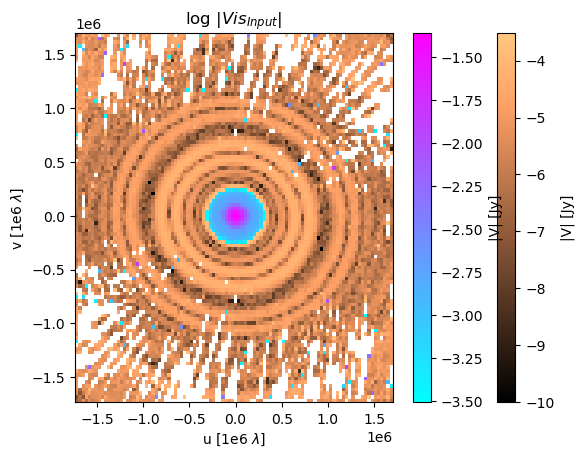

In [39]:
Plot_AS209.visibility_gridded_masked_input(percentil = 97)

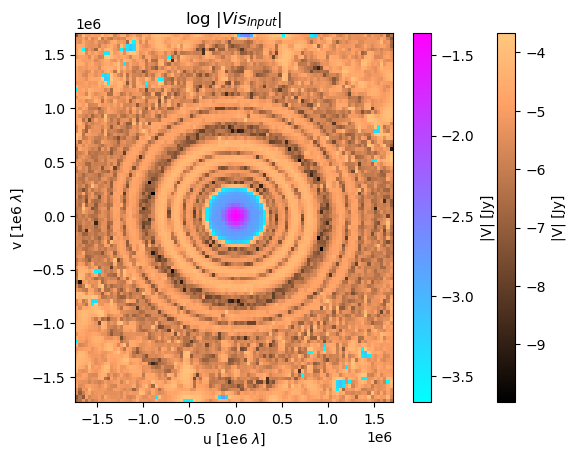

In [40]:
Plot_AS209.visibility_masked_model(percentil = 97)

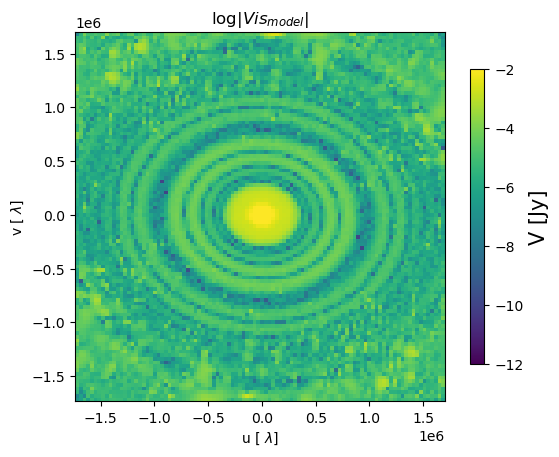

In [7]:
Plot_AS209.visibility_model()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_56193/2552710363.py:129: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


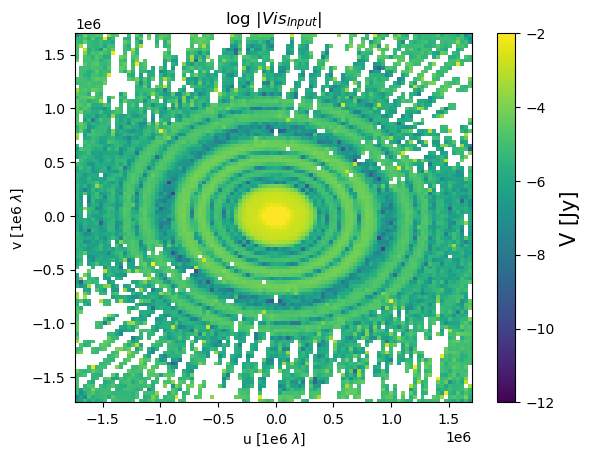

In [8]:
Plot_AS209.visibility_gridded_input()

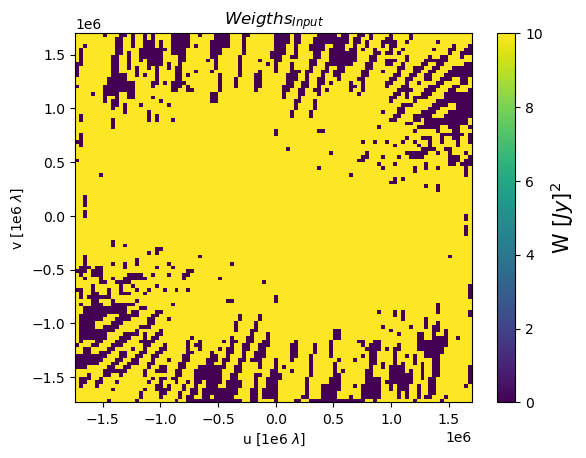

In [9]:
Plot_AS209.weights_gridded_input()

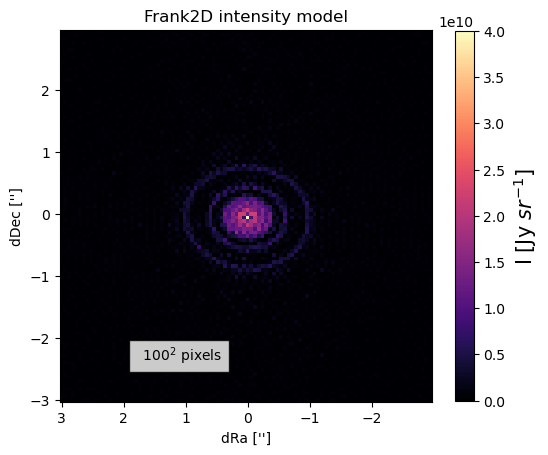

In [10]:
Plot_AS209.intensity_model()